In [68]:
import matplotlib.pyplot as plt #Gráficos
import numpy as np #Cálculos matemáticos e manipulação de arrays
import pandas as pd #Famoso pandas, manipulação de DataFrame etc.
import seaborn as sns #Gráficos

from sklearn.datasets import load_diabetes #Base de dados, scikit learn 

from src.config import DADOS_TRATADOS # Resultado EDA e salvo em formato parquet

sns.set_theme(palette="bright") #Layout do gráfico

In [37]:
dados = load_diabetes(as_frame=True, scaled=False)

dados

{'data':       age  sex   bmi      bp     s1     s2    s3    s4      s5     s6
 0    59.0  2.0  32.1  101.00  157.0   93.2  38.0  4.00  4.8598   87.0
 1    48.0  1.0  21.6   87.00  183.0  103.2  70.0  3.00  3.8918   69.0
 2    72.0  2.0  30.5   93.00  156.0   93.6  41.0  4.00  4.6728   85.0
 3    24.0  1.0  25.3   84.00  198.0  131.4  40.0  5.00  4.8903   89.0
 4    50.0  1.0  23.0  101.00  192.0  125.4  52.0  4.00  4.2905   80.0
 ..    ...  ...   ...     ...    ...    ...   ...   ...     ...    ...
 437  60.0  2.0  28.2  112.00  185.0  113.8  42.0  4.00  4.9836   93.0
 438  47.0  2.0  24.9   75.00  225.0  166.0  42.0  5.00  4.4427  102.0
 439  60.0  2.0  24.9   99.67  162.0  106.6  43.0  3.77  4.1271   95.0
 440  36.0  1.0  30.0   95.00  201.0  125.2  42.0  4.79  5.1299   85.0
 441  36.0  1.0  19.6   71.00  250.0  133.2  97.0  3.00  4.5951   92.0
 
 [442 rows x 10 columns],
 'target': 0      151.0
 1       75.0
 2      141.0
 3      206.0
 4      135.0
        ...  
 437    178.0
 438

In [4]:
dados.keys()

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])

In [5]:
print(dados["DESCR"])

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [6]:
df = dados["frame"]

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0,151.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0,75.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0,141.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0,206.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0,135.0


In [7]:
novos_nomes = {
    "age" : "idade",
    "sex" : "sexo",
    "bmi" : "imc",
    "bp" : "pressao_media",
    "s1" : "colesterol_total",
    "s2" : "ldl",
    "s3" : "hdl",
    "s4" : "colesterol_hdl",
    "s5" : "triglicerides",
    "s6" : "glicose",
    "target" : "target"    
}

df = df.rename(columns=novos_nomes)

df.head()

,idade,sexo,imc,pressao_media,colesterol_total,ldl,hdl,colesterol_hdl,triglicerides,glicose,target
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0,151.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0,75.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0,141.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0,206.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0,135.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   idade             442 non-null    float64
 1   sexo              442 non-null    float64
 2   imc               442 non-null    float64
 3   pressao_media     442 non-null    float64
 4   colesterol_total  442 non-null    float64
 5   ldl               442 non-null    float64
 6   hdl               442 non-null    float64
 7   colesterol_hdl    442 non-null    float64
 8   triglicerides     442 non-null    float64
 9   glicose           442 non-null    float64
 10  target            442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [9]:
df.describe()

,idade,sexo,imc,pressao_media,colesterol_total,ldl,hdl,colesterol_hdl,triglicerides,glicose,target
count,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000
mean,48.518100,1.468326,26.375792,94.647014,189.140271,115.439140,49.788462,4.070249,4.641411,91.260181,152.133484
std,13.109028,0.499561,4.418122,13.831283,34.608052,30.413081,12.934202,1.290450,0.522391,11.496335,77.093005
min,19.000000,1.000000,18.000000,62.000000,97.000000,41.600000,22.000000,2.000000,3.258100,58.000000,25.000000
25%,38.250000,1.000000,23.200000,84.000000,164.250000,96.050000,40.250000,3.000000,4.276700,83.250000,87.000000
50%,50.000000,1.000000,25.700000,93.000000,186.000000,113.000000,48.000000,4.000000,4.620050,91.000000,140.500000
75%,59.000000,2.000000,29.275000,105.000000,209.750000,134.500000,57.750000,5.000000,4.997200,98.000000,211.500000
max,79.000000,2.000000,42.200000,133.000000,301.000000,242.400000,99.000000,9.090000,6.107000,124.000000,346.000000


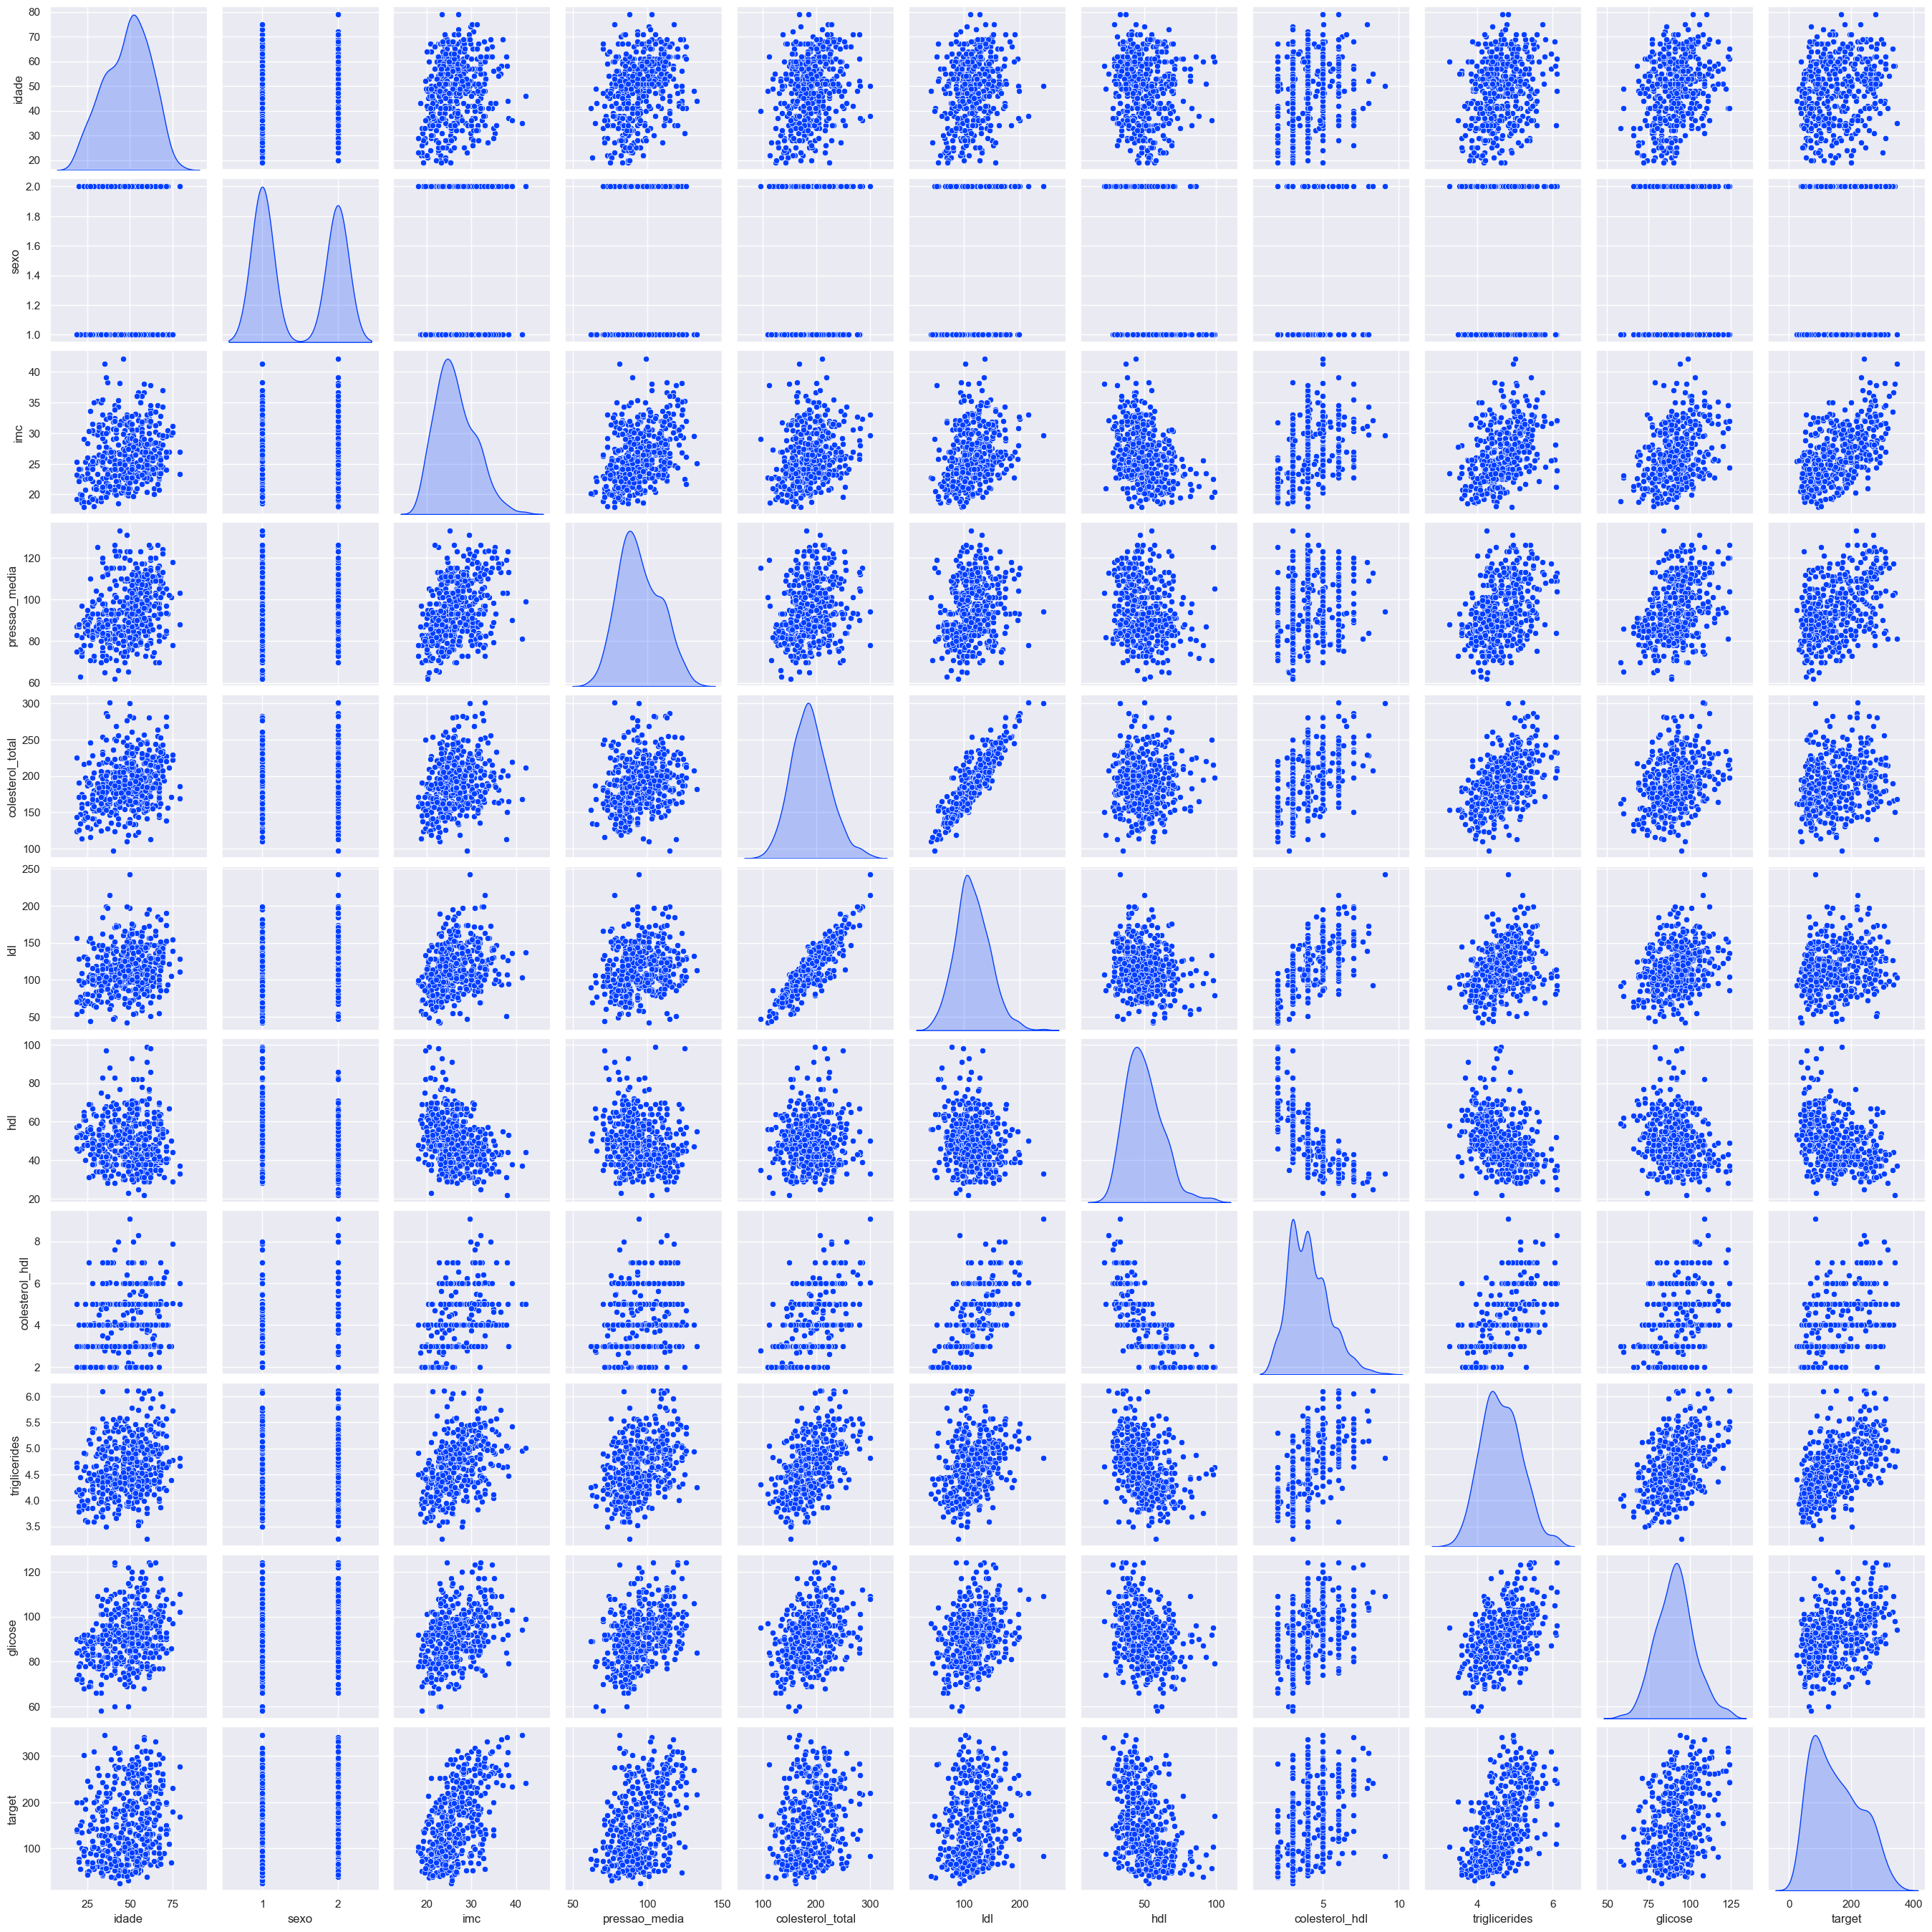

In [10]:
sns.pairplot(df, diag_kind="kde"); 

#Usei o método pairplot porque ele cria um gráfico de dispersão (scatter plot) para cada par de variáveis numéricas do DataFrame, permitindo visualizar relações lineares ou não lineares, identificar padrões ou outliers e ter uma visão geral dos dados.
#Para o método KDE, ele ajuda a mostrar a distribuição de cada variável individualmente, utilizando curvas de densidade.

In [11]:
df["colesterol_hdl"].value_counts()

#Podemos observar que essa coluna contém muitos números inteiros, o que gera uma concentração de linhas na horizontal ou vertical. Será necessário tratar esses dados, pois isso pode afetar a performance do modelo que vamos criar. A base extraída do próprio Scikit-Learn já trouxe esse campo tratado e arredondado, mas precisaremos ajustá-lo.

colesterol_hdl
3.00    128
4.00    108
5.00     68
6.00     33
2.00     28
       ... 
5.63      1
3.40      1
4.70      1
3.77      1
4.79      1
Name: count, Length: 66, dtype: int64

In [12]:
(3.0). is_integer()

#Temos muitos números inteiros representados como float, então será necessário quebrar ou ajustar esses valores para evitar problemas no modelo.

True

In [13]:
df["colesterol_hdl"].apply(lambda x: x.is_integer()).sum()

np.int64(380)

In [14]:
df.shape

(442, 11)

In [15]:
380 / df.shape[0]

0.8597285067873304

In [16]:
#.apply(lambda x: x.is_integer()).sum()
#Usamos essa função para contar quantos valores de colesterol_hdl são números inteiros disfarçados de float. Ela mostra que cerca de 85% da coluna tem esse padrão

A descrição da base sugere que colesterol_hdl deveria ser uma divisão (colesterol total / HDL), mas os dados não refletem isso. 

A maioria dos valores são inteiros arredondados.

In [18]:
(df["colesterol_total"] / df["hdl"]).apply(lambda x: x.is_integer()).sum()

#Fazendo a conta manualmente, identificamos apenas 19 valores inteiros e validamos que houve um tratamento prévio na base.

np.int64(19)

Vamos adotar um olhar crítico.

Esta é uma base de dados de contexto médico e, como não sou especialista na área, não sei exatamente o motivo pelo qual os dados foram tratados dessa forma. No entanto, seguiremos com a análise exploratória dos dados (EDA) por enquanto e, posteriormente, poderemos retornar ao tratamento dos dados quando formos preparar o modelo.

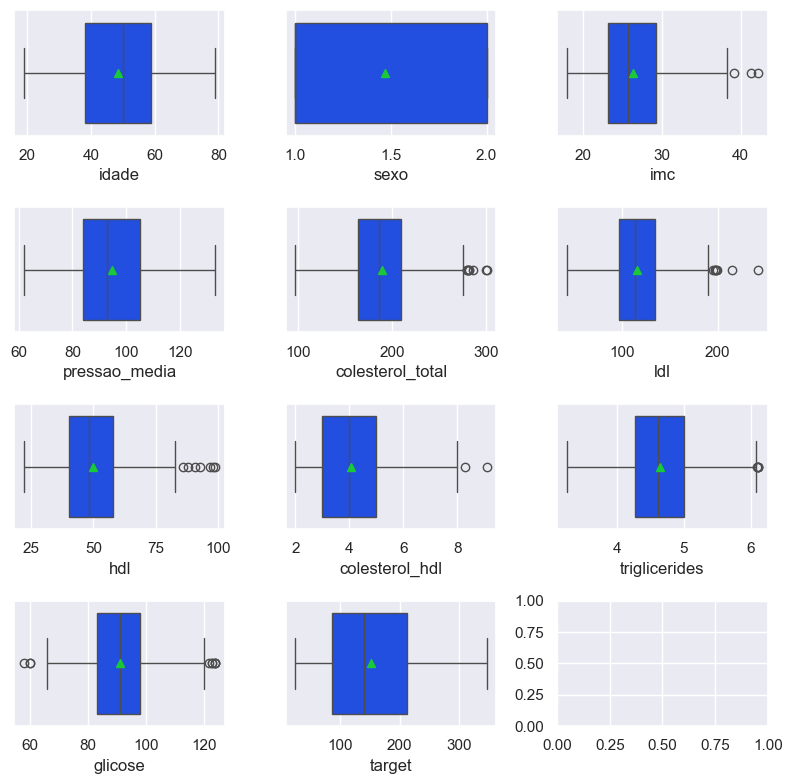

In [20]:
fig, axs = plt.subplots(4,3, figsize=(8,8)) # 4 linhas 3 colunas

for ax, coluna in zip(axs.flatten(), df.columns): # Gráfico Boxplot
    sns.boxplot(
        x=df[coluna],
        ax=ax,
        showmeans=True, #média
    )
plt.tight_layout() #Ajuste do layout
plt.show() 

#Outra forma de ver a distribuição dos dados. 

In [21]:
df.skew()

#Esse método ajuda a entender se os dados estão equilibrados ou se estão "puxados" para algum lado.
#Quanto mais próximo de 0, mais equilibrado e simétrico o dado está.

idade              -0.231382
sexo                0.127385
imc                 0.598148
pressao_media       0.290658
colesterol_total    0.378108
ldl                 0.436592
hdl                 0.799255
colesterol_hdl      0.735374
triglicerides       0.291754
glicose             0.207917
target              0.440563
dtype: float64

In [22]:
df.kurtosis()

#Esse método mede a curtose dos dados, ou seja, a forma como os dados se concentram em torno da média.
#Valores positivos indicam uma distribuição com caudas mais pesadas (mais dados extremos), e valores negativos indicam caudas mais leves.
#Quando mais próximo de 0, mais parecido com uma distribuição normal.

idade              -0.671224
sexo               -1.992811
imc                 0.095094
pressao_media      -0.532797
colesterol_total    0.232948
ldl                 0.601381
hdl                 0.981507
colesterol_hdl      0.444402
triglicerides      -0.134367
glicose             0.236917
target             -0.883057
dtype: float64

In [23]:
df.corr()

# Verificar a correlação entre as colunas.

,idade,sexo,imc,pressao_media,colesterol_total,ldl,hdl,colesterol_hdl,triglicerides,glicose,target
idade,1.000000,0.173737,0.185085,0.335428,0.260061,0.219243,-0.075181,0.203841,0.270774,0.301731,0.187889
sexo,0.173737,1.000000,0.088161,0.241010,0.035277,0.142637,-0.379090,0.332115,0.149916,0.208133,0.043062
imc,0.185085,0.088161,1.000000,0.395411,0.249777,0.261170,-0.366811,0.413807,0.446157,0.388680,0.586450
pressao_media,0.335428,0.241010,0.395411,1.000000,0.242464,0.185548,-0.178762,0.257650,0.393480,0.390430,0.441482
colesterol_total,0.260061,0.035277,0.249777,0.242464,1.000000,0.896663,0.051519,0.542207,0.515503,0.325717,0.212022
ldl,0.219243,0.142637,0.261170,0.185548,0.896663,1.000000,-0.196455,0.659817,0.318357,0.290600,0.174054
hdl,-0.075181,-0.379090,-0.366811,-0.178762,0.051519,-0.196455,1.000000,-0.738493,-0.398577,-0.273697,-0.394789
colesterol_hdl,0.203841,0.332115,0.413807,0.257650,0.542207,0.659817,-0.738493,1.000000,0.617859,0.417212,0.430453
triglicerides,0.270774,0.149916,0.446157,0.393480,0.515503,0.318357,-0.398577,0.617859,1.000000,0.464669,0.565883
glicose,0.301731,0.208133,0.388680,0.390430,0.325717,0.290600,-0.273697,0.417212,0.464669,1.000000,0.382483


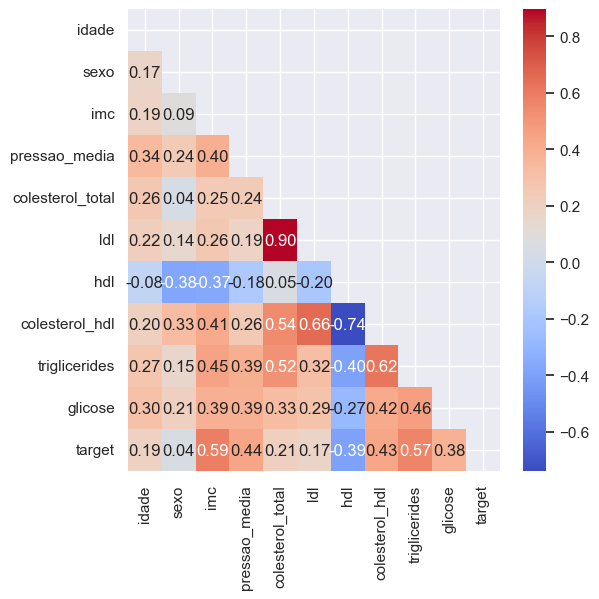

In [24]:
matriz = np.triu(df.corr()) #Deixa só o triângulo superior da matriz de correlação para evitar valores repetidos.

fig, ax = plt.subplots(figsize=(6,6))

sns.heatmap(df.corr(), # Gráfico mapa de calor
            mask=matriz,
            annot=True, #Valores
            fmt=".2f", #Reduzir as casas decimais
            ax=ax, #Sistema de eixos
            cmap="coolwarm" #Mapa de cores
)

plt.show()

A maior correlação com o nosso target é com a coluna 
IMC (0,59) e 
Triglicerides (0,57). 

Já a menor correlação é com o HDL, que apresentou -0,39.

Agora, vou exportar a base para um arquivo, para deixarmos de depender da importação do Scikit-Learn. Antes da exportação, vou otimizar a base, tratando os tipos de dados.

In [27]:
df.head()

,idade,sexo,imc,pressao_media,colesterol_total,ldl,hdl,colesterol_hdl,triglicerides,glicose,target
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0,151.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0,75.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0,141.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0,206.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0,135.0


In [28]:
df.tail()

,idade,sexo,imc,pressao_media,colesterol_total,ldl,hdl,colesterol_hdl,triglicerides,glicose,target
437,60.0,2.0,28.2,112.00,185.0,113.8,42.0,4.00,4.9836,93.0,178.0
438,47.0,2.0,24.9,75.00,225.0,166.0,42.0,5.00,4.4427,102.0,104.0
439,60.0,2.0,24.9,99.67,162.0,106.6,43.0,3.77,4.1271,95.0,132.0
440,36.0,1.0,30.0,95.00,201.0,125.2,42.0,4.79,5.1299,85.0,220.0
441,36.0,1.0,19.6,71.00,250.0,133.2,97.0,3.00,4.5951,92.0,57.0


In [29]:
# Checagem das colunas que podem ser números inteiros

colunas_valores_inteiros = []

for coluna in df.columns: #Vou buscar as colunas que podem ser inteiros e adicionar a variavel
    if df[coluna].apply(lambda x: x.is_integer()).all():
        colunas_valores_inteiros.append(coluna)

colunas_valores_inteiros

['idade', 'sexo', 'colesterol_total', 'glicose', 'target']

In [30]:
df[colunas_valores_inteiros] = df[colunas_valores_inteiros].astype(int)

df.info()

#Transformando as colunas em inteiro e verificando o resultado.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   idade             442 non-null    int64  
 1   sexo              442 non-null    int64  
 2   imc               442 non-null    float64
 3   pressao_media     442 non-null    float64
 4   colesterol_total  442 non-null    int64  
 5   ldl               442 non-null    float64
 6   hdl               442 non-null    float64
 7   colesterol_hdl    442 non-null    float64
 8   triglicerides     442 non-null    float64
 9   glicose           442 non-null    int64  
 10  target            442 non-null    int64  
dtypes: float64(6), int64(5)
memory usage: 38.1 KB


In [31]:
# Vou reduzir o tamanho da base 

# As colunas int64 para int8 ou int16

In [32]:
df[colunas_valores_inteiros] = df[colunas_valores_inteiros].apply(
    pd.to_numeric,
    downcast="integer"
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   idade             442 non-null    int8   
 1   sexo              442 non-null    int8   
 2   imc               442 non-null    float64
 3   pressao_media     442 non-null    float64
 4   colesterol_total  442 non-null    int16  
 5   ldl               442 non-null    float64
 6   hdl               442 non-null    float64
 7   colesterol_hdl    442 non-null    float64
 8   triglicerides     442 non-null    float64
 9   glicose           442 non-null    int8   
 10  target            442 non-null    int16  
dtypes: float64(6), int16(2), int8(3)
memory usage: 23.9 KB


Fazer essa transformação é importante. Embora nossa base seja pequena, é uma boa prática especialmente para bases maiores.

In [34]:
df[df.columns.difference(colunas_valores_inteiros)] = df[
    df.columns.difference(colunas_valores_inteiros)
].apply(pd.to_numeric, downcast="float")

df.info()

#Fiz a mesma coisa para as colunas com o formato float.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   idade             442 non-null    int8   
 1   sexo              442 non-null    int8   
 2   imc               442 non-null    float32
 3   pressao_media     442 non-null    float32
 4   colesterol_total  442 non-null    int16  
 5   ldl               442 non-null    float32
 6   hdl               442 non-null    float32
 7   colesterol_hdl    442 non-null    float32
 8   triglicerides     442 non-null    float32
 9   glicose           442 non-null    int8   
 10  target            442 non-null    int16  
dtypes: float32(6), int16(2), int8(3)
memory usage: 13.5 KB


Reduzimos o tamanho da base em aproximadamente 64,57%.

In [80]:
df.to_parquet(DADOS_TRATADOS, index=False)